<a href="https://colab.research.google.com/github/jawahirkhaleel/-jawahirkhaleel-/blob/main/xee_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade xee
!pip install -U geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 477.1/477.1 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.3 MB/s eta 0:00:00
  Attempting uninstall: earthengine-api
    Found existing installation: earthengine-api 1.5.24
    Uninstalling earthengine-api-1.5.24:
      Successfully uninstalled earthengine-api-1.5.24
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.6 MB/s eta 0:00:00
  Attempting uninstall: geemap
    Found existing installation: geemap 0.35.3
    Uninstalling geemap-0.35.3:
      Successfully uninstalled geemap-0.35.3


In [ ]:
import ee

In [ ]:
ee.Authenticate()
ee.Initialize(
    project = 'ee-jawahirkhaleel05',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

In [ ]:
import geemap

In [ ]:
map = geemap.Map(basemap = 'SATELLITE')
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [ ]:
roi = map.draw_last_feature.geometry()
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Polygon",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      [
                        [
                          82.814941,
                          30.410782
                        ],
                        [
                          78.837891,
                          28.748397
                        ],
                        [
                          70.72998,
                          36.084621
                        ],
                        [
                          74.838867,
                          37.561997
                        ],
                        [
                          82.111816,
                          30.996446
                        ],
                        [
                          82.814941,
                          30.410782
                        ]
                      ]
                    ]
                  },
                  "geodesic": {
                    "constantValue": false
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

In [ ]:
collection = (
    ee.ImageCollection("CSIC/SPEI/2_10").select('SPEI_12_month')
    .filterDate('1990','2026')
)


In [ ]:
collection

In [ ]:
import xarray as xr

In [ ]:
ds = xr.open_dataset(
    collection,
    engine = 'ee',
    geometry = roi,
    scale = 0.55,
    crs = 'EPSG:4326'
)


In [ ]:
ds = ds.sortby('time') * 1


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
df = ds.SPEI_12_month.to_dataframe().reset_index()[['time','SPEI_12_month']].set_index('time')


<Axes: xlabel='time'>

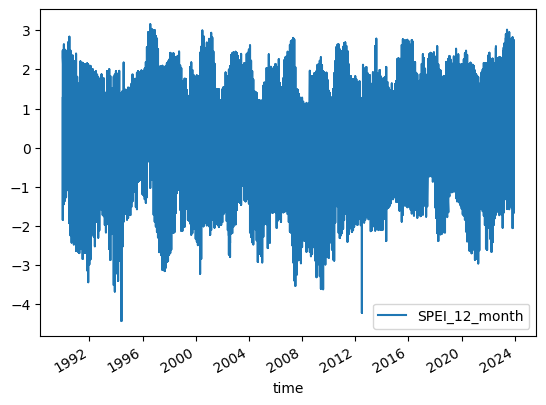

In [ ]:
df.plot()

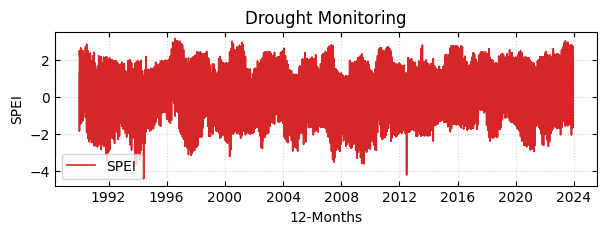

In [ ]:
fig, ax = plt.subplots(figsize = (7,2))

ax.plot(df.index, df, color = 'tab:red', lw = 1.2, ls = '-', label = 'SPEI')
ax.legend(loc = 'lower left')
ax.set_title('Drought Monitoring')
ax.grid(alpha = 0.5, ls = ':')
ax.tick_params(axis = 'both', direction = 'in', top = True, right = True)
ax.set_ylabel('SPEI')
ax.set_xlabel('12-Months')
plt.savefig('SPEI.png', bbox_inches = 'tight', dpi = 360)

In [ ]:
ax.plot(df.index, df, color = 'tab:red', lw = 1.2, ls = '-', label = 'SPEI')
ax.legend(loc = 'lower left')
ax.set_title('Drought Monitoring')
ax.grid(alpha = 0.5, ls = ':')
ax.tick_params(axis = 'both', direction = 'in', top = True, right = True)
ax.set_ylabel('SPEI')
ax.set_xlabel('12-Months')
plt.savefig('SPEI.png', bbox_inches = 'tight', dpi = 360)


<Figure size 640x480 with 0 Axes>

In [ ]:
plt.savefig('SPEI.png', bbox_inches = 'tight', dpi = 360)

<Figure size 640x480 with 0 Axes>